<h2>Imports</h2>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import os

<h2>Useful Functions</h2>

In [ ]:
# Opens the CSV file from the MAXM86161 Software
def opencsv(name):
    with open(name) as fp:
        skip = next(filter(
            lambda x: x[1].startswith('timestamp'),
            enumerate(fp)
        ))[0]
    df = pd.read_csv(name, skiprows=skip)
    df.drop(df.tail(4).index,
            inplace = True)
    df['timestamp']=df['timestamp'].astype(float).astype(int)
    return df

# 5th Order Butterworth Lowpass Filter Implementation
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, fs, cutoff, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = signal.filtfilt(b, a, data)
    return y

# 5th Order Butterworth Bandpass Filter Implementation 
def butter_bandpass(cutoff_l, cutoff_h, fs, order=5):
    nyq = 0.5 * fs
    b, a = signal.butter(order, [cutoff_l/nyq, cutoff_h/nyq], btype='band', analog=False)
    return b, a

def butter_bandpass_filter(data, fs, cutoff_l, cutoff_h, order=5):
    b, a = butter_bandpass(cutoff_l, cutoff_h, fs, order=order)
    y = signal.filtfilt(b, a, data)
    return y

# Finds peaks in PPG and ECG signals
def peakfind_ecg(x, distance=40, prominence=0.3):
    peaks, _ = scipy.signal.find_peaks(x, distance=distance, prominence=prominence)
    return peaks

def peakfind_ppg(x, distance=40, prominence=200):
    peaks, _ = scipy.signal.find_peaks(x, distance=distance, prominence=prominence)
    return peaks

# Aligns PPG signals from the wrist and finger
def align_in_ref(p_in, p_ref, prom_ref=200, prom_in=200):
    peaks_in = peakfind_ppg(p_in, prominence=prom_in)
    peaks_ref = peakfind_ppg(p_ref, prominence=prom_ref)
    anchor = peaks_in[1]
    return min([pd - anchor for pd in peaks_ref], key=abs)

# Removes spikes from the pressure sensor reading
def remove_large_spikes(signal, threshold):
    smoothed_signal = medfilt(signal, kernel_size=3)
    spike_locations = np.abs(signal - smoothed_signal) > threshold
    cleaned_signal = np.where(spike_locations, smoothed_signal, signal)

    return cleaned_signal

# Converts timestamp strings to a unix timestamp
def convert_to_unix(timestamp_str, pattern, timezone_str='Asia/Singapore'):
    timestamp_format = pattern
    timestamp = datetime.strptime(timestamp_str, timestamp_format)
    input_timezone = pytz.timezone(timezone_str)
    timestamp = input_timezone.localize(timestamp)
    singapore_timezone = pytz.timezone("Asia/Singapore")
    timestamp_singapore = timestamp.astimezone(singapore_timezone)
    unix_timestamp = int(timestamp_singapore.timestamp())

    return unix_timestamp

# Aligns ECG and PPG signals
def find_peak_shift(decg, dppg):
    l=min(len(decg), len(dppg))
    decg = decg[:l]
    dppg = dppg[:l]
    
    r = dict()
    cr, _ = scipy.stats.pearsonr(decg, dppg)
    r.update({0: cr})
    
    for i in range(1, l//2):
        cr, _ = scipy.stats.pearsonr(decg[i:], dppg[:-i])
        r.update({i: cr})
    for i in range(1, l//2):
        cr, _ = scipy.stats.pearsonr(dppg[i:], decg[:-i])
        r.update({-i: cr})
    
    return int(max(r, key=r.get))

def reset_time(col, st, fact=1000):
    return (col - st) / fact

def get_prominence(p, fs):
    bpfed = butter_bandpass_filter(p, fs, 0.8, 3.5)
    bpfed -= min(bpfed)
    
    return median(bpfed)/3

def subtract_ac(time, sig):
    peaks = peakfind_ppg(sig, prominence=get_prominence(sig, 100)/100)
    line = interpolate.CubicSpline(time[peaks], sig[peaks])
    ac = (sig - line(time))*-1
    return ac


<h2>fetching data</h2>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

file_path = 'data/finger_1000.csv' 

# 1. Carregar o arquivo (low_memory=False ajuda a evitar o primeiro aviso)
df = pd.read_csv(file_path, skiprows=6, low_memory=False)
df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')

df = df.dropna(subset=['timestamp'])

df = df.dropna(axis=1, how='all')

df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# Definir o índice
df = df.set_index('datetime')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


# LEDs
ax1.plot(df.index, df['LEDC1'], label='LEDC1 (Verde)', color='green')
ax1.plot(df.index, df['LEDC2'], label='LEDC2 (Vermelho)', color='red')
ax1.plot(df.index, df['LEDC3'], label='LEDC3 (IR)', color='darkred')
ax1.set_title('Sinais do Sensor Ótico (PPG)')
ax1.set_ylabel('Amplitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accelerometer
ax2.plot(df.index, df['ACCX'], label='X', alpha=0.7)
ax2.plot(df.index, df['ACCY'], label='Y', alpha=0.7)
ax2.plot(df.index, df['ACCZ'], label='Z', alpha=0.7)
ax2.set_title('Dados do Acelerômetro')
ax2.set_ylabel('Aceleração')
ax2.set_xlabel('Tempo')
ax2.legend()
ax2.grid(True, alpha=0.3)

df = df[df['LEDC2'] > 50000]


plt.tight_layout()
plt.show()

<h2>Filtering</h2>

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. DSP CONFIGURATION
# ==========================================
fs = 100.0        
low_cut = 0.5    
high_cut = 4.0   
channel = 'LEDC2'

# ==========================================
# 2. SIGNAL PREPARATION (Artifact Removal)
# ==========================================
df_filtered = df.copy()

# Remove motion artifacts (sudden drops below 78k) by replacing them with NaN
df_filtered['clean_signal'] = np.where(df_filtered[channel] < 78000, np.nan, df_filtered[channel])

# Interpolate to fill gaps, keeping the time domain linear for the DSP filter
df_filtered['clean_signal'] = df_filtered['clean_signal'].interpolate(method='linear').bfill().ffill()
clean_data = df_filtered['clean_signal'].values 

# ==========================================
# 3. BANDPASS FILTER APPLICATION
# ==========================================
# Isolate the physiological frequency band (0.5Hz to 4.0Hz)
filtered_signal = butter_bandpass_filter(clean_data, fs, low_cut, high_cut)
df_filtered[f'{channel}_filtered'] = filtered_signal

# ==========================================
# 4. BPM EXTRACTION (FFT)
# ==========================================
# Compute the 1D Discrete Fourier Transform
N = len(filtered_signal)
fft_result = np.fft.fft(filtered_signal)
freqs = np.fft.fftfreq(N, d=1/fs) 

# Extract magnitude and keep only the positive half of the spectrum
fft_mag = np.abs(fft_result[:N//2])
freqs = freqs[:N//2]

# Create a mask to search strictly within the human heart rate range
valid_mask = (freqs >= low_cut) & (freqs <= high_cut)
valid_freqs = freqs[valid_mask]
valid_mags = fft_mag[valid_mask]

# Find the frequency peak with the highest energy
peak_idx = np.argmax(valid_mags)
heart_rate_hz = valid_freqs[peak_idx]

# Convert Hz (beats per second) to BPM (beats per minute)
bpm_fft = heart_rate_hz * 60.0

print(f"Heart Rate: {bpm_fft:.1f} BPM (Dominant Freq: {heart_rate_hz:.2f} Hz)")

<h2>Plot</h2>

In [ ]:
fig = plt.figure(figsize=(16, 16))
ax1 = fig.add_subplot(4, 1, 1)
ax2 = fig.add_subplot(4, 1, 2, sharex=ax1)
ax3 = fig.add_subplot(4, 1, 3, sharex=ax1)
ax4 = fig.add_subplot(4, 1, 4)            


ax1.plot(df_filtrado.index, df_filtrado[channel], label='Raw Signal', color='red', alpha=0.7)
ax1.set_title(f'Passo 1: Sinal PPG Bruto ({channel})')
ax1.set_ylabel('Amplitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_filtrado.index, df_filtrado['sinal_limpo'], label='Interpolated Signal', color='gray', alpha=0.7)
ax2.set_title(f'Passo 2: Sinal PPG Preparado')
ax2.set_ylabel('Amplitude')
ax2.legend()
ax2.grid(True, alpha=0.3)


ax3.plot(df_filtrado.index, df_filtrado[f'{channel}_filtrado'], label='Filtered Signal (0.5 - 4.0 Hz)', color='green')
ax3.set_title(f'Passo 3: Sinal Filtrado no Tempo (BPM FFT: {bpm_fft:.1f})')
ax3.set_ylabel('Amplitude')
ax3.set_xlabel('Tempo')
ax3.set_ylim(-1500, 1000) 

tempo_inicial = df_filtrado.index[2000] 
tempo_final = df_filtrado.index[3000]   
ax1.set_xlim(tempo_inicial, tempo_final)

ax3.legend()
ax3.grid(True, alpha=0.3)


ax4.plot(frequencias_validas, magnitudes_validas, color='purple', label='Energy FFT')
ax4.plot(frequencia_cardiaca_hz, magnitudes_validas[indice_pico], 'ro', markersize=10, label=f'Pico Cardíaco ({frequencia_cardiaca_hz:.2f} Hz)')
ax4.set_title('Frequency Domain')
ax4.set_ylabel('Energy / Magnitude')
ax4.set_xlabel('Frequency (Hertz)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h2>My Data</h2>

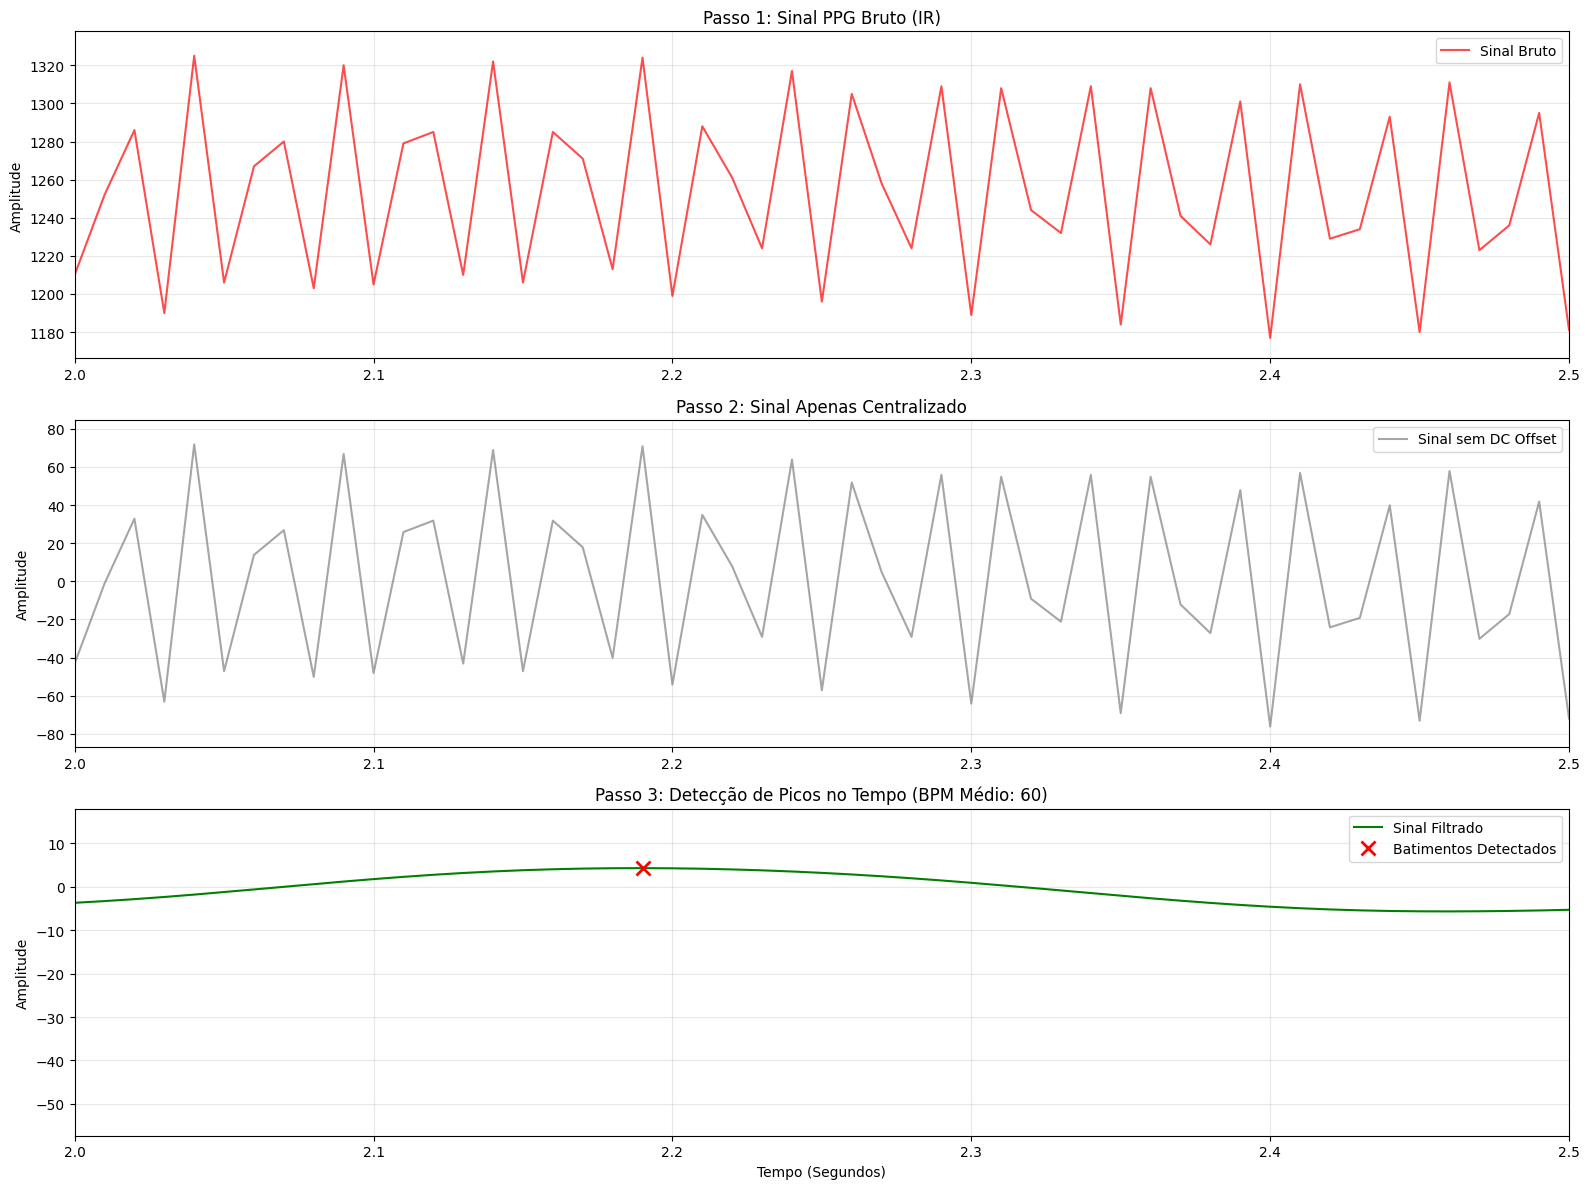

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# --- 1. CARREGAR OS DADOS ---
df = pd.read_csv('data/sensor_data.csv')
channel = 'IR'
TAXA_AMOSTRAGEM = 100 

df_filtrado = pd.DataFrame()
df_filtrado[channel] = df[channel]

# Eixo X em segundos (1 amostra = 10ms)
df_filtrado['tempo_segundos'] = np.arange(len(df_filtrado)) / TAXA_AMOSTRAGEM

# --- 2. PREPARAÇÃO DO SINAL ---
df_filtrado['sinal_limpo'] = df_filtrado[channel] - df_filtrado[channel].mean()

# --- 3. FILTRAGEM PASSA-BANDA (0.5 a 4.0 Hz) ---
nyquist = 0.5 * TAXA_AMOSTRAGEM
low = 0.5 / nyquist
high = 4.0 / nyquist
b, a = butter(4, [low, high], btype='bandpass')
sinal_filtrado = filtfilt(b, a, df_filtrado['sinal_limpo'])
df_filtrado[f'{channel}_filtrado'] = sinal_filtrado

# --- 4. DETECÇÃO DE PICOS (DOMÍNIO DO TEMPO) ---
distancia_minima_amostras = int(TAXA_AMOSTRAGEM * 0.3) 

# Procuramos os picos no sinal filtrado
indices_picos, _ = find_peaks(
    df_filtrado[f'{channel}_filtrado'], 
    distance=distancia_minima_amostras,
    prominence=np.std(df_filtrado[f'{channel}_filtrado']) * 0.5 # Exige que o pico tenha um destaque mínimo
)

# Pega o tempo exato (em segundos) em que cada pico ocorreu
tempos_dos_picos = df_filtrado['tempo_segundos'].iloc[indices_picos].values

# Calcula a diferença de tempo entre um pico e o próximo (Inter-Beat Interval)
se_tem_picos_suficientes = len(tempos_dos_picos) >= 2

if se_tem_picos_suficientes:
    intervalos_entre_batimentos = np.diff(tempos_dos_picos) # Array com o tempo (segundos) entre cada batimento
    tempo_medio_batimento = np.mean(intervalos_entre_batimentos)
    
    # Se 1 batimento leva 'X' segundos, quantos cabem em 60 segundos?
    bpm_calculado = 60.0 / tempo_medio_batimento
else:
    bpm_calculado = 0

# --- 5. PLOTAGEM DOS GRÁFICOS ---
fig = plt.figure(figsize=(16, 12))
ax1 = fig.add_subplot(3, 1, 1)
ax2 = fig.add_subplot(3, 1, 2, sharex=ax1)
ax3 = fig.add_subplot(3, 1, 3, sharex=ax1)

# GRÁFICO 1
ax1.plot(df_filtrado['tempo_segundos'], df_filtrado[channel], label='Sinal Bruto', color='red', alpha=0.7)
ax1.set_title(f'Passo 1: Sinal PPG Bruto ({channel})')
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# GRÁFICO 2
ax2.plot(df_filtrado['tempo_segundos'], df_filtrado['sinal_limpo'], label='Sinal sem DC Offset', color='gray', alpha=0.7)
ax2.set_title('Passo 2: Sinal Apenas Centralizado')
ax2.set_ylabel('Amplitude')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# GRÁFICO 3 (Com as marcações dos batimentos)
ax3.plot(df_filtrado['tempo_segundos'], df_filtrado[f'{channel}_filtrado'], label='Sinal Filtrado', color='green')

# Desenha um 'X' vermelho exatamente onde o algoritmo detectou um batimento
ax3.plot(tempos_dos_picos, df_filtrado[f'{channel}_filtrado'].iloc[indices_picos], 'rx', markersize=10, markeredgewidth=2, label='Batimentos Detectados')

ax3.set_title(f'Passo 3: Detecção de Picos no Tempo (BPM Médio: {bpm_calculado:.0f})')
ax3.set_ylabel('Amplitude')
ax3.set_xlabel('Tempo (Segundos)')
ax3.set_ylim(df_filtrado[f'{channel}_filtrado'].min() * 1.5, df_filtrado[f'{channel}_filtrado'].max() * 1.5) 
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)


tempo_inicial_zoom = 2.0  # Começa no segundo 2
tempo_final_zoom = 2.5    # Termina no segundo 7
ax1.set_xlim(tempo_inicial_zoom, tempo_final_zoom)

plt.tight_layout()
plt.show()